# **Spectral type pdf flagger part 2: SPLIT (Source-type Probability from Likelihood Identification Tool).**

In part 1, we computed the PDFs of physical quantities of each source and characterized them. In this second notebook, we calibrate SPLIT with the input catalog, knowing which source correspond to what type, then verify if we find the good source type again.

## **0. Initialization**

### 0.1. Packages

In [1]:
### Libs ###
from imports import *

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(base_dir)

# Custom libraries
import scripts.statsplot as ssp
import scripts.utils as sutils
%matplotlib inline

#--- Stats & Maths---
from scipy.stats import norm
from sklearn.feature_selection import f_classif
import scipy.interpolate as sip
from scipy.stats import gaussian_kde

### 0.2. Tables

In [2]:
#--- The initial table, used in LePHARE, the table in which is gathered the statistics compute from each onesource
#and the table of best fit statistical parameters ---
training_sample = pd.read_csv(f'{base_dir}/catalogs/DC2/dc2_starpdf_features.csv')
# trilegal = pd.read_csv(f'{base_dir}/catalogs/DC2/trilegal_starpdf_features.csv')

In [3]:
star_training_sample = training_sample[training_sample["ts_truth_type"]==2]
gal_training_sample = training_sample[training_sample["ts_truth_type"]==1]

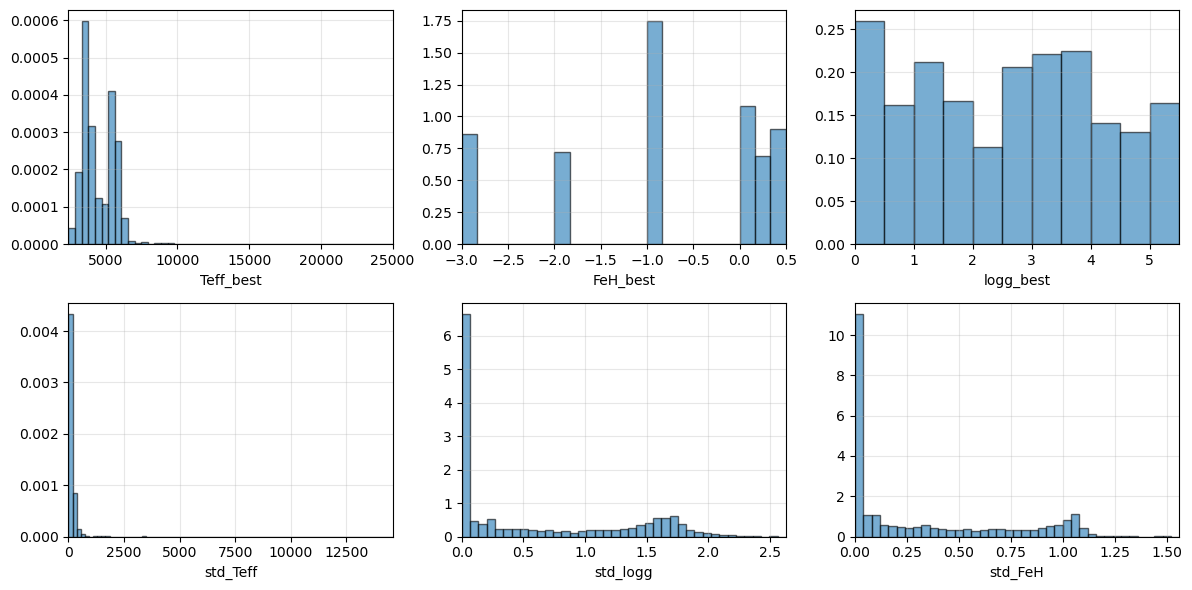

In [4]:
ssp.histograms(star_training_sample, xrange=None, log=False, bins=[50, 22, 12, 80, 40, 40, 40], 
                 col=['Teff_best', 'FeH_best', 'logg_best', #col to plot
                      'std_Teff', 'std_logg', 'std_FeH'],
                      density=True, alpha=0.6) #histkwargs

# ssp.histograms(gal_training_sample, xrange=None, log=False, bins=[50, 22, 12, 80, 40, 40, 40],
#                  col=['Teff_best', 'FeH_best', 'logg_best', #col to plot
#                       'std_Teff', 'std_logg', 'std_FeH'],
#                       density=True, alpha=0.6) #histkwargs

## **1. SPLIT training**

Now that we have fully characterized the star-pdfs, we can use them as a discretizer. To do so, we look at the distribution of each statistical feature of a "training sample", depending of the source type. Then for a source for which the type is unknow we see if it fits better the usual statistics of a star or a galaxy. It is like a likelihood of a likelihood. 

### 1.1 Utils

In [5]:
def make_bins(mask_min, mask_max, nbins, logscale=False):
    if logscale:
        return np.logspace(np.log10(max(mask_min, 1e-6)),
                            np.log10(mask_max), nbins)
    else:
        return np.linspace(mask_min, mask_max, nbins)

def shift_bins(edges):
    edges = np.asarray(edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    first = centers[0] - (centers[1] - centers[0])
    last  = centers[-1] + (centers[-1] - centers[-2])
    return np.concatenate([[first], centers, [last]])


### 1.2 Make statistics distribution functions

In [6]:
from scipy.integrate import quad
class SPLIT_TRAINING:
    """
    Prepare the statistical feature distributions for the classification.
    """

    def list_to_pdf(self, data, interp=False, bins=100, recenter_bins=True, xrange=None, smooth_eps=1e-9, normalize=True):
        """
        Compute the pdf from a data array.

        Parameters
        ----------
        data: list or np.darray
            Array to compute the pdf from.
        interp: Bool or str.
            Interpolation method to build the pdf.
        bins: int or list or np.darray.
            Bins used to compute the histogram used in <scipy.interpolate.{interp}> methods.
        recenter_bins: bool.
            If True, recenter the bins over the bin edges. Useful when using a list in bins
        xrange: tuple.
            Range to compute the pdf within.
        smooth_eps: float.
            Zero probability value.
        
        Returns
        -------
        pdf: pdf function.
        """
        if interp in ('scott', 'silverman') or isinstance(interp,(float,int)) and interp!=False:
            kde = gaussian_kde(data, bw_method=interp)
            def pdf(x):
                return kde(x)
            return pdf

        if recenter_bins==True and not isinstance(bins, int):
            new_bins = shift_bins(bins)
            counts, _ = np.histogram(data, bins=new_bins, range=xrange, density=True)
            x = bins
        else:
            counts, bin_edges = np.histogram(data, bins=bins, range=xrange, density=True)
            x=0.5 * (bin_edges[:-1] + bin_edges[1:])
        
        counts = counts + smooth_eps
        # --- Interpolation ---
        if interp == 'pchip':
            pdf_raw = sip.PchipInterpolator(x, counts, extrapolate=False)
        else:
            pdf_raw = sip.interp1d(x, counts, kind=interp, bounds_error=False, fill_value=0.0)

        # --- Normalization ---
        if normalize==True:
            xmin, xmax = min(x), max(x)
            Z, _ = quad(pdf_raw, xmin, xmax, limit=1000)

            if Z <= 0 or not np.isfinite(Z):
                raise ValueError("PDF normalization failed (integral <= 0).")

            def pdf(x):
                return pdf_raw(x) / Z
        else:
            pdf = pdf_raw

        return pdf

    def pdfs_from_arrays(self, arrays, **ltpkwargs):
        """
        Return the pdf from two arrays and compute the weight if specified.

        Parameters
        ----------
        arrays: tuple of (list or np.darray)
            Arrays to compute the pdfs from.
        ltpkwargs: args of <list_to_pdf> method.
        Returns
        -------
        pdfs: list of pdf methods.
        """
        pdfs = []
        for dist in arrays:
            pdf = self.list_to_pdf(dist, **ltpkwargs)
            pdfs.append(pdf)

        return pdfs

    def compute_weight(self, source_feats, source_labels, method='f_classif'):
        """
        Compute weight by comparing feature distributions between several classes.
        The weight determine if the feature is relevant to be used to compare the classes.

        Parameters
        ----------
        source_feats: list of (list or np.darray)
            Array of dimension N_sources x N_features.
            Each element corresponds to a source, and each element of a row is a statistical feature.
        source_labels: list of (str, int...).
            The list of label corresponding to each source.
        method: str.
            The method to use to compute weight (fisher or f_classic)
        Returns
        -------
        List of weights of length N_features.
        """
        source_feats = np.asarray(source_feats)
        source_labels = np.asarray(source_labels)

        if method == 'fisher':
            classes = np.unique(source_labels)
            n_features = source_feats.shape[1]
            weights = np.zeros(n_features)
            global_mean = np.mean(source_feats, axis=0)
            for j in range(n_features):
                num = 0.0  # inter-class variance
                den = 0.0  # intra-class variance
                for c in classes:
                    mask = source_labels == c
                    x_c = source_feats[mask, j]
                    if len(x_c) < 2:
                        continue
                    mean_c = np.mean(x_c)
                    var_c = np.var(x_c)
                    num += len(x_c) * (mean_c - global_mean[j])**2
                    den += len(x_c) * var_c
                weights[j] = num / den if den > 0 else 0.0

        elif method == 'f_classif':
            f_statistic, _ = f_classif(source_feats, source_labels)
            weights = f_statistic

        else:
            raise NotImplementedError(
                f"Weight method '{method}' not recognized."
            )

        # --- normalisation ---
        weights = np.nan_to_num(weights, nan=0.0, posinf=0.0)
        if np.sum(weights) > 0:
            weights /= np.sum(weights)
        return weights

    def pdfs_from_sample(self, training_df, label_column, scols=None, exclude_scols=False, 
                        compute_weight=False, weight_method='fisher', selectKbest=None, 
                        custo_bins_interp=None, **ltpkwargs):
        """
        Compute the pdf for each class, for each features.

        Parameters
        ----------
        dfs: pandas.dataframe.
            df to compute the pdfs from. It must contain at leats a label column,
            and the features columns to compute the pdfs from. Each row is a source.
        label_column: str.
            Column holding the label attributed to each source. 
        scols: str or list of.
            Selected columns to compute the pdfs from is [{col_name}],
            or to ignore if ~[{col_name}].
        exclude_scols: bool.
            If True, scols are now the columns to exclude from the computations.
        compute_weight: bool.
            If true, return the weight of each statistical feature.
        custo_bins_interp: tuple (str, list) or list of.
            If specified, for each col in custo_bins_interp[0], list_to_pdf uses the bins in custo_bins_interp[1].
        ltpkwargs: args of <list_to_pdf> method.
        Returns
        -------
        pdfs_dict: Dict
            pdf functions, with weights if True.
        """

        # --- Select feature columns ---
        if scols is not None:
            if exclude_scols==True:
                cols = [c for c in training_df.columns
                            if c not in scols
                            and c != label_column]
            elif exclude_scols==False:
                cols = [c for c in training_df.columns
                            if c in scols
                            and c != label_column]
                
        else:
            cols = training_df.drop(columns=[label_column]).columns.tolist()
        # --- extract features / labels ---
        features_values = training_df[cols].values.astype(float) # Nsources(rows) x Nfeatures(cols)
        source_labels = training_df[label_column].values # Nsources
        unique_labels = np.unique(source_labels)
        # --- compute weights ---
        if compute_weight==True:
            weights = self.compute_weight(features_values, source_labels, method=weight_method)
            # select the k best weight features from weights
            if isinstance(selectKbest, int):
                idx = np.argsort(weights)[::-1][:selectKbest]
                cols = [cols[i] for i in idx]
                weights = weights[idx]
                features_values = features_values[:, idx]

                weights /= np.sum(weights)
        else:
            weights = np.ones(len(cols)) / len(cols)

        # --- Build pdf dictionary ---
        # len(source_labels)*N_features = N_pdfs
        custo_map = None
        if custo_bins_interp is not None:
            custo_map = {}
            for item in custo_bins_interp:
                if len(item) != 3:
                    raise ValueError(
                        "Each element of custo_bins_interp must be (col, bins, interp)"
                    )
                col, bins, interp = item
                custo_map[col] = {"bins": bins, "interp": interp}

        pdf_dict = {}
        for i, col in enumerate(cols):
            pdfs = {}

            for label in unique_labels:
                mask = source_labels == label
                data = features_values[mask, i]

                local_kwargs = ltpkwargs
                # --- Apply custom bins / interp if specified ---
                if custo_map is not None and col in custo_map:
                    if custo_map[col]["bins"] is not None:
                        local_kwargs["bins"] = custo_map[col]["bins"]
                    if custo_map[col]["interp"] is not None:
                        local_kwargs["interp"] = custo_map[col]["interp"]
                pdfs[label] = self.list_to_pdf(data, **local_kwargs)
            pdf_dict[col] = {"pdfs": pdfs, "weight": weights[i]}

        return pdf_dict
        


### 1.3 Test on the sample

In [7]:
split_training=SPLIT_TRAINING()

We selected the SEDs using a discrete list of physical quantities. Thus we can use it to make the bins of the probability function since Teff_best, FeH_best and logg_best are discrete too.

In [8]:
teff_values = list(range(800, 7200, 400)) + list(range(7200, 12001, 600)) + list(range(12500, 25001, 5000)) + list(range(25000, 50001, 5000))
logg_values = np.arange(0.0, 5.6, 0.5)
feh_values = [-3, -2, -1, 0.0, 0.3, 0.5]

In [9]:
#Note: the star sed library used for the tests held 1622 seds at the creation of this notebook
sed_id_bins = np.arange(0,1622,1)

In [10]:
pdf_dict = split_training.pdfs_from_sample(
    training_sample,
    label_column="ts_truth_type",
    scols=["source_id", "npeaks_Teff", "npeaks_logg", 'npeaks_FeH', 'mt_match_objectId', 'ts_truth_type', 'chi2_best','imag', 'imag_err'],
    compute_weight=True,
    weight_method="f_classif",
    exclude_scols=True,
    selectKbest=None,
    bins=500,
    interp=False,
    custo_bins_interp=[("Teff_best", teff_values, False),("logg_best", logg_values, False),("FeH_best", feh_values, False),('best_sed_id', sed_id_bins,None)],
    recenter_bins=True,
    normalize=False
)

/home/hallouin/miniconda3/envs/lephare/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


In [11]:
def prob_plot(data, pdfs, labels=None, feature=None,
                bins=50, xrange=None):
    """
    Plot PDFs and histograms for one feature.

    Parameters
    ----------
    data : pandas.DataFrame or list of arrays
        Data to plot histograms from.
    pdfs : list of callables or dict
        PDFs corresponding to each class (ignored if pdfs_dict is provided).
    labels : list, optional
        Class labels if data AND pdfs are arrays. Can use column name of class labels
        if data is DataFrame OR pdfs a dict. 
    bins : int or array-like
        Histogram bins.
    recenter_bins : bool
        Recenter bins if array-like.
    feature : str, optional
        Feature name to plot (required if pdfs_dict is provided).
    xrange : tuple, optional
        (xmin, xmax) range for plotting.
    """
    # --- Handle pdfs format ---
    if isinstance(pdfs, dict):
        pdf_list = list(pdfs[feature]['pdfs'].values())
    elif isinstance(pdfs, list):
        pdf_list = pdfs
    else:
        raise ValueError('pdfs must be a list of callables or a dict')

    # --- Handle labels format ---
    if isinstance(labels, str) and isinstance(data, pd.DataFrame):
        label_list = list(np.unique(data[labels]))
    elif isinstance(labels, list):
        label_list = labels
    elif labels==None and isinstance(pdfs, dict):
        label_list = list(pdfs[feature]['pdfs'].keys())
    elif labels==None and not isinstance(pdfs, dict):
        label_list = [f"class {i}" for i in range(len(pdfs))]
    else:
        raise ValueError('Labels must be a list of labels or a str coupled with a pandas.dataframe.')

    # --- Handle data format ---
    if isinstance(data, pd.DataFrame):
        if feature is None:
            raise ValueError("feature must be specified when data is a DataFrame.")
        if not isinstance(labels, str):
            raise ValueError("labels must be provided as str when data is a DataFrame.")
        data_arrays = [data.loc[data[labels] == l, feature].values for l in label_list]
    else:
        data_arrays = [np.asarray(d) for d in data]

    if len(data_arrays) != len(pdf_list):
        raise ValueError("Number of data arrays and pdfs must match.")

    # --- Plot ---
    plt.figure(figsize=(6, 5))
    cmap = plt.get_cmap("tab20")
    i=0
    for arr, pdf, lab in zip(data_arrays, pdf_list, label_list):
        if isinstance(bins, int):
            _, bin_edges, _ = plt.hist(arr, bins=bins, density=True, label=f"hist {lab}", color=cmap(i), alpha=0.3)
            x=0.5 * (bin_edges[:-1] + bin_edges[1:])
        if isinstance(bins, (list, np.ndarray)):
            x = np.asarray(bins)
            plt.hist(arr, bins=shift_bins(bins), density=True, label=f"hist {lab}", color=cmap(i), alpha=0.3)
            
        plt.plot(x, pdf(x), linestyle='--', label=f"pdf {lab}", c=cmap(i))
        i+=2

    plt.xlabel(feature if feature is not None else "x")
    plt.ylabel("PDF")
    plt.legend()
    plt.tight_layout()
    plt.show()


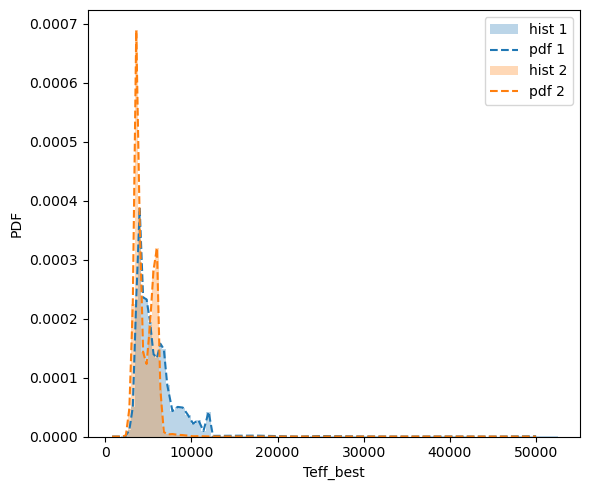

In [12]:
%matplotlib inline
# prob_plot(data=training_sample, pdfs=pdf_dict, labels='ts_truth_type', feature='std_logg', bins=500)
# prob_plot(data=training_sample, pdfs=pdf_dict, labels='ts_truth_type', feature='best_sed_id', bins=sed_id_bins)
prob_plot(data=training_sample, pdfs=pdf_dict, labels='ts_truth_type', feature='Teff_best', bins=teff_values)

# Note that if you use normalized pdf (normalize=True), it will not exactly fit the normalized histograms (density=True).
# Note 2: for the moment the most efficient technic seems to do not interpolate when the sample is big

## **2. SPLIT**

The main part of SPLIT.

In [14]:
# for key in pdf_dict.keys():
#     print(key,':', pdf_dict[key]['weight'])

In [ ]:
class SPLIT:
    """
    Class where appends the main part of split. 

    Init with the pdf dict created with <SPLIT_TRAINING>.
    """
    def __init__(self, pdf_dict):
        self.pdf_dict = pdf_dict
        self.features = list(pdf_dict.keys())
        self.classes = list(
            next(iter(pdf_dict.values()))['pdfs'].keys()
        )

    def feature_loglikelihood(self, x, feature, eps=1e-12):
        """
        Compute log p(x | class) for a given feature.
        """
    
        pdfs = self.pdf_dict[feature]['pdfs']

        logL = []

        for c in self.classes:
            p = pdfs[c](x)
            p = np.maximum(p, eps)
            logL.append(np.log(p))

        return np.array(logL)

    def class_prob(self, onesource, priors=None, use_weights=False, eps=1e-12):
        """
        Compute the probability of a source to belong to each class using <self.post_prob>.

        Parameters:
        -----------
        onesource: the source to evaluate the class on. Can be a list of features corresponding to the pdfs

        priors: None or list of float of length = len(pdfs).
            If specified, take priors in account.
        use_weights: bool
            If True, uses the feature weights specified in pdfs.
        
        Return:
        -------
        probs: list of floats
            List of probabilies to belong to the classes.
            
        """
        n_classes = len(self.classes)

        if priors is None:
            priors = np.ones(n_classes) / n_classes
        else:
            priors = np.asarray(priors)

        log_post = np.log(priors)

        for feature in self.features:

            x = onesource[feature]

            logL_feat = self.feature_loglikelihood(x, feature, eps)

            if use_weights:
                w = self.pdf_dict[feature]['weight']
                log_post += w * logL_feat
            else:
                log_post += logL_feat

        # softmax stable
        max_log = np.max(log_post)
        exp_log = np.exp(log_post - max_log)
        probs = exp_log / np.sum(exp_log)

        return probs

    def classify_sample(self, df, priors=None, use_weights=False):

        results = []

        for _, row in df.iterrows():
            probs = self.class_prob(
                row,
                priors=priors,
                use_weights=use_weights
            )
            results.append(probs)

        posterior = np.vstack(results)
        
        return pd.DataFrame(
            posterior,
            columns=[f"P_{c}" for c in self.classes],
            index=df.index
        )


Initialize split with the dictionnary of feature pdfs

In [17]:
split = SPLIT(pdf_dict)

Compute probabilities

In [18]:
probs = split.classify_sample(training_sample, priors=None, use_weights=True)

Merge with the table

In [21]:
final = pd.concat([training_sample, probs], axis=1)

In [59]:
mask = (final['ts_truth_type']==2) & (final['imag'] > 24) & (final['imag'] < 30)
final[mask]

,source_id,npeaks_Teff,peakratio_Teff,std_Teff,npeaks_logg,peakratio_logg,std_logg,npeaks_FeH,peakratio_FeH,std_FeH,...,logg_best,FeH_best,chi2_best,sec_best_sed_id,sec_Teff_best,sec_logg_best,sec_FeH_best,sec_chi2_best,P_1,P_2
0,1651413688361421449,1,0.028793,609.066670,1,0.942599,1.690101,0,0.727342,1.035656,...,3.0,-3.0,5.54270,913,4800.0,3.5,-3.0,5.54510,0.845358,0.154642
1,1651413688361451863,1,0.008300,69.456168,1,0.287778,0.746080,1,0.151169,0.794221,...,3.5,0.5,19.80900,749,4000.0,3.0,0.5,20.14200,0.617206,0.382794
428,1651413688361420917,1,0.016603,231.113364,2,0.864079,1.698205,1,0.573412,0.698694,...,1.5,0.0,2.26500,531,3200.0,2.0,0.0,2.32180,0.590432,0.409568
795,1651413688361452730,1,0.011432,214.281666,5,0.634319,1.664299,1,0.469615,0.776555,...,3.5,0.0,3.24880,657,3600.0,4.0,0.0,3.53720,0.714263,0.285737
931,1651413688361421101,1,0.020675,334.664629,1,0.645686,1.906822,2,0.716621,1.092522,...,5.5,-2.0,6.21000,565,3200.0,5.0,-2.0,6.40450,0.698985,0.301015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265653,1651220174314966045,1,0.008215,53.682110,3,0.432515,1.457374,1,0.413080,1.027714,...,2.5,0.0,0.12188,735,4000.0,2.0,0.0,0.56925,0.601654,0.398346
265936,1651220174314967227,1,0.010367,180.909794,1,0.729266,1.465764,0,0.675605,1.004495,...,2.5,-3.0,12.11900,746,4000.0,3.0,-3.0,12.14700,0.671925,0.328075
266099,1651220174314966329,1,0.014877,265.516440,1,0.629351,1.491955,1,0.411517,0.876148,...,3.5,0.5,6.99810,761,4000.0,4.0,0.5,7.10440,0.734402,0.265598
266130,1651220174314967284,1,0.014094,206.012654,1,0.666504,1.839893,0,0.535381,0.888331,...,5.5,-3.0,7.24350,931,4800.0,5.0,-3.0,7.35050,0.625472,0.374528


# **3. Statistical study**

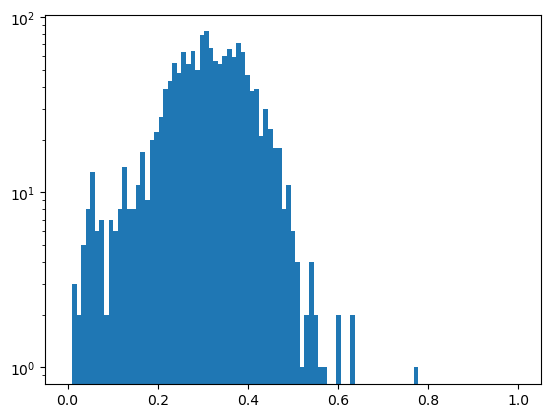

In [60]:
%matplotlib inline
plt.figure()
plt.hist(final[mask]['P_2'],bins=np.linspace(0,1,100),log=True)
plt.show()